Success: 1000 keV -> Eff: -1.8660e+00
Success: 3000 keV -> Eff: -1.6020e+00
Success: 5000 keV -> Eff: -1.6200e+00
Success: 8000 keV -> Eff: -1.6140e+00


/tmp/ipykernel_735/3004495860.py:57: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(hpge_fit, x_data, y_data)


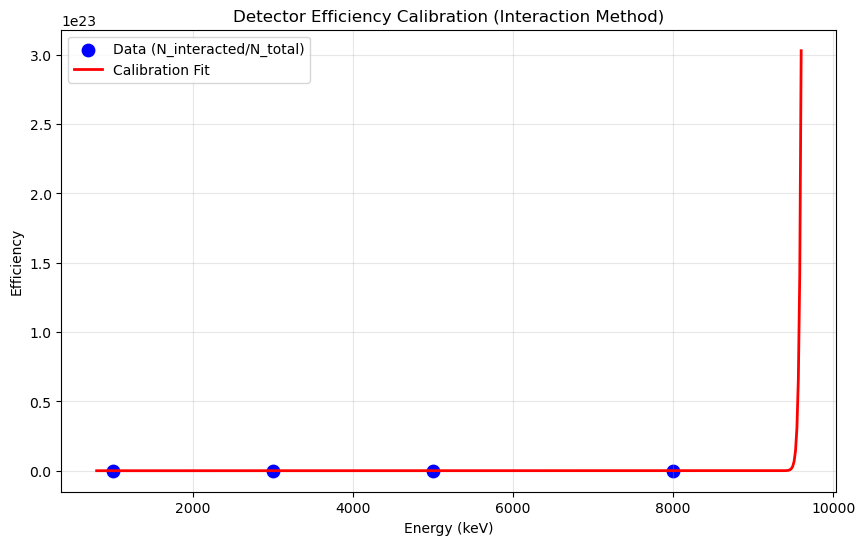

In [13]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Configuration
file_configs = [
    {"file": "1MeV_gamma.root", "energy": 1000},
    {"file": "3MeV_gamma.root", "energy": 3000},
    {"file": "5MeV_gamma.root", "energy": 5000},
    {"file": "8MeV_gamma.root", "energy": 8000}
]

N_TOTAL = 500 # Set this once globally

def get_efficiency(filename, target_energy):
    """
    Calculates efficiency by taking the total particles and 
    deducting those that escaped without any interaction (de == 0).
    """
    with uproot.open(filename) as file:
        tree = file["t"] 
        # Using the 'de' branch for deposited energy
        de = tree["de"].array() 
        
        # Count particles that escaped without ANY interaction
        n_escaped_clean = np.sum(de == 0)
        
        # Number that stayed to interact at least once
        n_interacted = N_TOTAL - n_escaped_clean
        
        return n_interacted / N_TOTAL

# 2. Extract Data
x_data = []
y_data = []

for config in file_configs:
    try:
        eff = get_efficiency(config["file"], config["energy"])
        x_data.append(config["energy"])
        y_data.append(eff)
        print(f"Success: {config['energy']} keV -> Eff: {eff:.4e}")
    except Exception as e:
        print(f"Error processing {config['file']}: {e}")

x_data = np.array(x_data)
y_data = np.array(y_data)

# 3. Fitting Function (Industry Standard for HPGe)
def hpge_fit(E, a, b, c):
    lnE = np.log(E)
    return np.exp(a + b*lnE + c*(lnE**2))

if len(x_data) > 1:
    # Perform the fit
    popt, _ = curve_fit(hpge_fit, x_data, y_data)

    # 4. Plotting
    x_plot = np.linspace(min(x_data)*0.8, max(x_data)*1.2, 500)
    y_plot = hpge_fit(x_plot, *popt)

    plt.figure(figsize=(10, 6))
    plt.scatter(x_data, y_data, color='blue', s=80, label='Data (N_interacted/N_total)')
    plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='Calibration Fit')

    # Formatting
    plt.xlabel('Energy (keV)')
    plt.ylabel('Efficiency')
    plt.title('Detector Efficiency Calibration (Interaction Method)')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Not enough data points found to create a curve.")